### ⋆✴︎˚｡⋆ An AI model that when presented with gene expression data from skin samples, detects biomarkers for psoriasis and outputs a probability/risk score for psoriasis.  
# ------------------------------------------------------
#### Dataset used: https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE13355  
#### **GSE13355 — 122 skin samples used out of 180 total (58 PP, 58 PN, 64 NN)**
#### -PP (psoriasis) 
#### -NN (healthy) 
#### *not including PN (healthy skin from psoriasis patients) for simplicity*
#### 54,675 genes reduced to 10,923 after cleaning

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import GEOparse

print("All libraries loaded! Yay!")

All libraries loaded! Yay!


In [24]:
# gse = GEOparse.get_GEO(geo="GSE13355", destdir="./data")
# print("Download complete!")  
# ^^ used this code to get the dataframe from the ncbi GEO. Since it's already in my project files... 
df = pd.read_csv("data/cleaned_expression.csv", index_col=0)
y = pd.read_csv("data/labels.csv", index_col=0).squeeze()

print("Data loaded!")
print("Shape:", df.shape)
print("Psoriasis (1):", sum(y == 1))
print("Healthy (0):", sum(y == 0))

Data loaded!
Shape: (122, 10923)
Psoriasis (1): 58
Healthy (0): 64


In [4]:
print("Number of samples:", len(gse.gsms))
print("Number of platforms:", len(gse.gpls))
print()
print("First 5 sample names:")
for name in list(gse.gsms.keys())[:5]:
    print(" ", name)

Number of samples: 180
Number of platforms: 1

First 5 sample names:
  GSM337197
  GSM337198
  GSM337199
  GSM337200
  GSM337201


In [5]:
first_sample = gse.gsms["GSM337197"]

print("Sample title:", first_sample.metadata["title"][0])
print("Sample type:", first_sample.metadata["source_name_ch1"][0])
# print("Gene expression data (first 5 rows):")
print(first_sample.table.head())

Sample title: Individual_4288_NN_sample
Sample type: skin_tissue
      ID_REF     VALUE
0  1007_s_at  0.039595
1    1053_at -0.253107
2     117_at -0.364125
3     121_at -0.276912
4  1255_g_at -0.176441


In [6]:
print("genes per sample:", len(first_sample.table))

genes per sample: 54675


In [7]:
for name, sample in list(gse.gsms.items())[:15]:
    title = sample.metadata["title"][0]
    print(name, "→", title)

GSM337197 → Individual_4288_NN_sample
GSM337198 → Individual_4379_NN_sample
GSM337199 → Individual_4394_NN_sample
GSM337200 → Individual_4598_NN_sample
GSM337201 → Individual_4689_NN_sample
GSM337202 → Individual_4908_NN_sample
GSM337203 → Individual_4935_NN_sample
GSM337204 → Individual_4952_NN_sample
GSM337205 → Individual_4981_NN_sample
GSM337206 → Individual_4999_NN_sample
GSM337207 → Individual_5030_NN_sample
GSM337208 → Individual_5050_NN_sample
GSM337209 → Individual_5063_NN_sample
GSM337210 → Individual_5079_NN_sample
GSM337211 → Individual_5093_NN_sample


In [ ]:
pp_count = 0  # psoriasis lesional
pn_count = 0  # psoriasis uninvolved
nn_count = 0  # healthy 

for name, sample in gse.gsms.items():
    title = sample.metadata["title"][0]
    if "PP" in title:
        pp_count += 1
    elif "PN" in title:
        pn_count += 1
    elif "NN" in title:
        nn_count += 1
#how many in each category, pp, pn, and nn
print("PP (psoriasis lesional):", pp_count)
print("PN (psoriasis uninvolved):", pn_count)
print("NN (healthy normal):", nn_count)
print("Total:", pp_count + pn_count + nn_count) 


PP (psoriasis lesional): 58
PN (psoriasis uninvolved): 58
NN (healthy normal): 64
Total: 180


In [ ]:
samples = {}
labels = {}
#Get rid of PN, as it will confuse the model at this stage for being "in between"
for name, sample in gse.gsms.items():
    title = sample.metadata["title"][0]
    if "PP" in title:
        samples[name] = sample.table.set_index("ID_REF")["VALUE"]
        labels[name] = 1  
    elif "NN" in title:
        samples[name] = sample.table.set_index("ID_REF")["VALUE"]
        labels[name] = 0 
#the dataframe we will use
df = pd.DataFrame(samples).T
print("Shape of our data table:", df.shape)
print("(rows = different patient, columns = genes)")

Shape of our data table: (122, 54675)
(rows = different patient, columns = genes)


In [10]:
df.head()

ID_REF,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,1405_i_at,1431_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
GSM337197,0.039595,-0.253107,-0.364125,-0.276912,-0.176441,0.086250,0.221729,-0.320840,-1.126897,-0.327913,...,-0.081636,-0.328450,-0.423008,-0.270105,-0.226956,-0.319601,-0.176648,-0.192687,-0.073284,-0.122345
GSM337198,0.329659,0.204677,-0.043381,0.115037,-0.140106,0.193882,0.212560,-0.064011,0.311538,-1.041916,...,-0.273890,0.682386,0.755164,0.677561,0.483312,0.662629,0.367697,0.462876,0.213415,0.266793
GSM337199,0.217226,-0.132534,0.469793,-0.115331,0.113417,-0.383677,-0.095971,0.785377,0.380125,-0.537814,...,-0.036066,0.253201,0.201827,0.182643,0.071606,0.205802,0.161489,0.163201,0.159849,0.171542
GSM337200,0.367991,-0.057208,-0.527403,-0.167975,-0.063135,-0.060888,0.139160,-0.192299,-0.370054,-0.842812,...,-0.127747,0.507668,0.496547,0.332177,0.317952,0.376557,0.388445,0.359106,0.208954,0.275985
GSM337201,0.167704,-0.402179,0.500486,-0.057145,-0.140319,0.187447,-0.046260,0.873412,0.489758,-0.467239,...,-0.080696,0.533420,0.654474,0.527365,0.503262,0.635598,0.416690,0.414428,0.290288,0.303844


In [11]:
y = pd.Series(labels)

print("Number of labels:", len(y))
print("Psoriasis (1):", sum(y == 1))
print("Healthy (0):", sum(y == 0))
print()
print("Do labels match data rows?", list(y.index) == list(df.index))

Number of labels: 122
Psoriasis (1): 58
Healthy (0): 64

Do labels match data rows? True


In [12]:
print("Genes before removing controls:", df.shape[1])

# remove any column that starts with AFFX, these are the controls for the researchers 
df = df.loc[:, ~df.columns.str.startswith("AFFX")]

# count after
print("Genes after removing controls:", df.shape[1])

Genes before removing controls: 54675
Genes after removing controls: 54613


In [13]:
# count before
print("Genes before removing missing values:", df.shape[1])

# drop any column that has even one missing value
df = df.dropna(axis=1)

# count after
print("Genes after removing missing values:", df.shape[1])

Genes before removing missing values: 54613
Genes after removing missing values: 54613


In [14]:
#removing genes of low variance. If a gene has same level across all samples 
#it is basically useless 

# calculate variance for every gene
gene_variances = df.var()

print("Lowest variance:", gene_variances.min().round(4))
print("Highest variance:", gene_variances.max().round(4))
print("Average variance:", gene_variances.mean().round(4))

Lowest variance: 0.0012
Highest variance: 19.3638
Average variance: 0.1026


In [ ]:
#visualization is key.

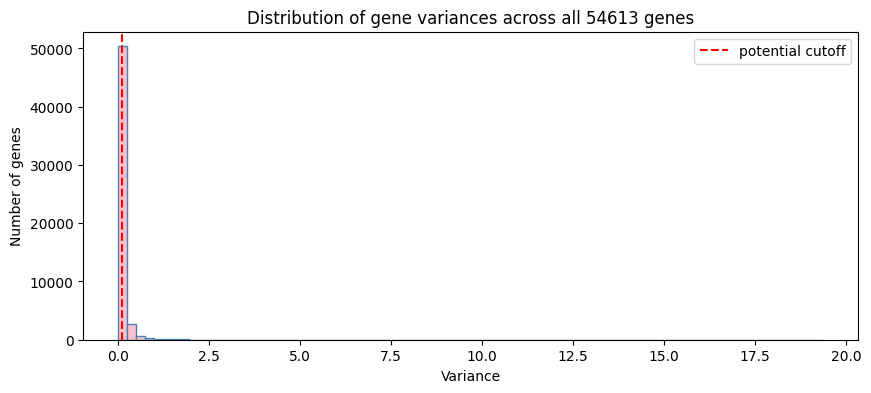

In [16]:
plt.figure(figsize=(10, 4))
plt.hist(gene_variances, bins=80, color='pink', edgecolor='steelblue')
plt.xlabel("Variance")
plt.ylabel("Number of genes")
plt.title("Distribution of gene variances across all 54613 genes")
plt.axvline(x=0.1, color='red', linestyle='--', label='potential cutoff')
plt.legend()
plt.show()

In [17]:
# calculate the 80th percentile variance cutoff (the genes that vary the least)
cutoff = gene_variances.quantile(0.80)
print("Variance cutoff:", cutoff.round(4))

# keep only genes above that cutoff
df = df.loc[:, gene_variances > cutoff]

print("Genes before:", 54613)
print("Genes after:", df.shape[1])

Variance cutoff: 0.1201
Genes before: 54613
Genes after: 10923


In [18]:
# save the cleaned data table
df.to_csv("data/cleaned_expression.csv")

# save the labels
y.to_csv("data/labels.csv")

print("Saved!")
print("Data shape:", df.shape)

Saved!
Data shape: (122, 10923)


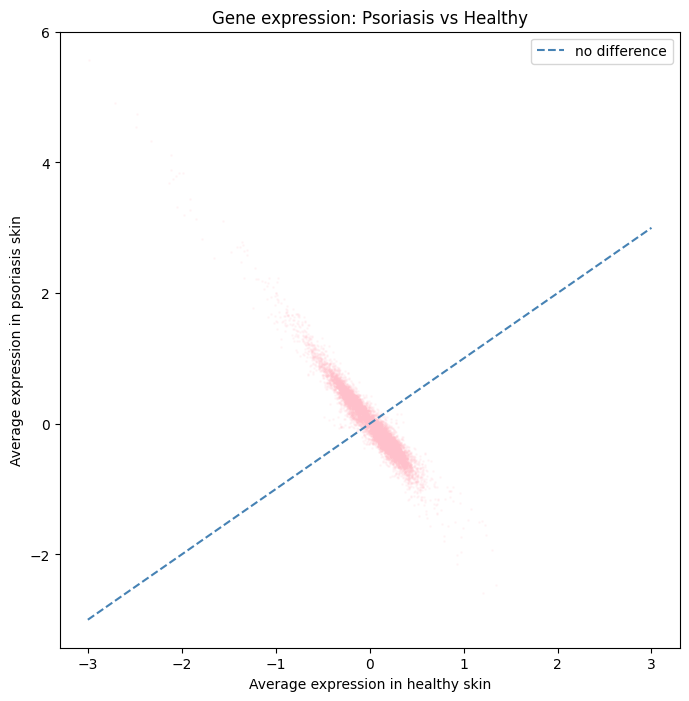

In [31]:
df_psoriasis = df[y == 1]
df_healthy = df[y == 0]
#avg expression per group
avg_psoriasis = df_psoriasis.mean()
avg_healthy = df_healthy.mean()

plt.figure(figsize=(8, 8)) 
plt.scatter(avg_healthy, avg_psoriasis, alpha=0.1, s=1, color='pink')
plt.xlabel("Average expression in healthy skin")
plt.ylabel("Average expression in psoriasis skin")
plt.title("Gene expression: Psoriasis vs Healthy")
plt.plot([-3, 3], [-3, 3], color='steelblue', linestyle='--', label='no difference')
plt.legend()
plt.show()

In [35]:
from scipy import stats

# t-test for every single gene
pvalues = {}
tstatistics = {}

for gene in df.columns:
    psoriasis_values = df_psoriasis[gene]
    healthy_values = df_healthy[gene]
    t_stat, p_val = stats.ttest_ind(psoriasis_values, healthy_values)
    pvalues[gene] = p_val
    tstatistics[gene] = t_stat

# convert to a new dataframe
results = pd.DataFrame({
    'pvalue': pvalues,
    'tstatistic': tstatistics
})

print("T-tests meaaawhjajksadj")
print("Genes tested:", len(results))
print("Genes with p < 0.05:", sum(results['pvalue'] < 0.05))

T-tests meaaawhjajksadj
Genes tested: 10923
Genes with p < 0.05: 9872


*bonferroni correction* is used to prevent false positives when running  
multiple tests on the same dataset 
it keeps the error rate controlled by dividing the original significance level 
by the number of tests

In [ ]:
# apply Bonferroni correction 
bonferroni_cutoff = 0.05 / len(results)
print("Bonferroni cutoff:", bonferroni_cutoff)

significant_genes = results[results['pvalue'] < bonferroni_cutoff]
print("Genes after Bonferroni correction:", len(significant_genes))

# sort by most significant (smallest p-value first)
significant_genes = significant_genes.sort_values('pvalue')
print("\nTop 10 most significant genes:")
print(significant_genes.head(10))

Bonferroni cutoff: 4.577497024626934e-06
Genes after Bonferroni correction: 8164

Top 10 most significant genes:
                    pvalue  tstatistic
203691_at    1.467534e-113   92.768125
41469_at     5.158082e-112   90.018686
207356_at    7.737187e-109   84.615798
232170_at     1.258641e-96   66.607364
206561_s_at   5.944115e-95   64.444208
220322_at     1.130534e-83   51.498493
209720_s_at   2.696195e-82   50.094055
227735_s_at   6.775192e-82   49.692638
227736_at     8.153511e-82   49.612318
211906_s_at   9.345827e-81   48.565332


In [37]:
#still way too many freaking genes oml 
#new dataframe will include only top 300  
top_genes = significant_genes.head(300).index.tolist()
df_filtered = df[top_genes]
print("Final feature set shape:", df_filtered.shape)
print("(rows = samples, columns = selected genes)")

Final feature set shape: (122, 300)
(rows = samples, columns = selected genes)


In [38]:
df_filtered.to_csv("data/filtered_expression.csv") 
print("saved mwahaha")

saved mwahaha


### *SUMMARY OF DATA CLEANING*
- raw genes from the chip = 54675
- removed control probes (AFFX-) = 54613
- removed low variance genes = 10923
- kept only statistically significant ones = 300

Now it's time to build the model: first by splitting the data into a training set and a test set

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    df_filtered,  # our 300 genes
    y,            # our labels (0 or 1)
    test_size=0.2,        # 20% for testing
    random_state=42,      # makes the split reproducible
    stratify=y            # keeps psoriasis/healthy ratio equal in both splits
)

print("Training samples:", len(X_train))
print("Test samples:", len(X_test))

Training samples: 97
Test samples: 25


In [41]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# train the model
model = LogisticRegression(
    max_iter=1000,       # gives it enough time to converge
    random_state=42
)
model.fit(X_train_scaled, y_train)

print("Model trained!")

Model trained!


In [44]:
from sklearn.metrics import classification_report, roc_auc_score

# get predictions on test set
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# print results
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Healthy', 'Psoriasis']))
print("AUROC Score:", roc_auc_score(y_test, y_prob).round(4))
#pls work oml 
#ignore error

Classification Report:
              precision    recall  f1-score   support

     Healthy       1.00      1.00      1.00        13
   Psoriasis       1.00      1.00      1.00        12

    accuracy                           1.00        25
   macro avg       1.00      1.00      1.00        25
weighted avg       1.00      1.00      1.00        25



AttributeError: 'float' object has no attribute 'round'

In [43]:
print("AUROC Score:", round(roc_auc_score(y_test, y_prob), 4))


AUROC Score: 1.0


In [45]:
from sklearn.model_selection import cross_val_score
from sklearn.pipeline import Pipeline
# combine scaling and model into one pipeline
# this prevents data leakage between folds
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(max_iter=1000, random_state=42))
])
# run 5-fold cross-validation
scores = cross_val_score(pipeline, df_filtered, y, cv=5, scoring='roc_auc')
print("AUROC per fold:", scores.round(4))
print("Average AUROC:", scores.mean().round(4))
print("Standard deviation:", scores.std().round(4))

AUROC per fold: [1. 1. 1. 1. 1.]
Average AUROC: 1.0
Standard deviation: 0.0


In [50]:
def psoriasis_risk(sample):
    #probability
    prob = model.predict_proba(sample)[0][1]
    
    # print result
    print("Psoriasis Risk Assessment")
    print(f"Risk Score: {prob:.1%}")
    if prob >= 0.7:
        print("Risk Level: HIGH")
    elif prob >= 0.4:
        print("Risk Level: MODERATE")
    else:
        print("Risk Level: LOW")

# test it on the first test sample
psoriasis_risk(X_test_scaled[:1])
print("Actual label:", "Psoriasis" if y_test.iloc[0] == 1 else "Healthy")  

print()
print("Sample 2")
psoriasis_risk(X_test_scaled[1:2])
print("Actual:", "Psoriasis" if y_test.iloc[1] == 1 else "Healthy")

print()
print("Sample 3")
psoriasis_risk(X_test_scaled[2:3])
print("Actual:", "Psoriasis" if y_test.iloc[2] == 1 else "Healthy")

Psoriasis Risk Assessment
Risk Score: 0.0%
Risk Level: LOW
Actual label: Healthy

Sample 2
Psoriasis Risk Assessment
Risk Score: 0.0%
Risk Level: LOW
Actual: Healthy

Sample 3
Psoriasis Risk Assessment
Risk Score: 100.0%
Risk Level: HIGH
Actual: Psoriasis


*pickle* is a library used to convert complex objects into a byte steam (pickling) that can be saved to a file/database/transmitted to a network and later reconstructed back into the original object (unpickling) 

Here, it is used to save trained models as .pkl files to avoid retraining

In [ ]:
import pickle
# save the model
with open("model.pkl", "wb") as f:
    pickle.dump(model, f)

# save the scaler
with open("scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

# save the list of top genes
with open("top_genes.pkl", "wb") as f:
    pickle.dump(top_genes, f)

print("Model saved!")
print("Scaler saved!")
print("Top genes saved!")

Model saved!
Scaler saved!
Top genes saved!
